# Temporal Patterns & Signal Decomposition

**Question**: Can we separate known natural variation (season, radon washout) from unexplained deviations — and what fraction of Radnett variance is predictable noise?

Approach:
1. Monthly aggregation to quantify annual seasonal pattern (snow shielding)
2. Rolling 10-day baseline to isolate short-term residuals (mirrors DSA's own alarm method)
3. Residual peak cataloguing — candidate anomalies
4. Rain effect validation using Civil Defence rainfall flag
5. Cross-station correlation — which stations provide unique information?

---

## Setup

In [22]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data_loader import load_radnett, load_station_locations, load_civil_defence
from src.utils import save_figure, classify_uptime, STATION_TYPE_COLORS, UPTIME_COLORS


pd.set_option("display.float_format", "{:.4f}".format)

## 1. Prepare data

In [2]:
radnett = load_radnett()
stations = load_station_locations()

# Load placement info from DSA report
report = pd.read_csv(PROJECT_ROOT / "data" / "reference" / "dsa_report_table1_radnett.csv", comment="#")
placement_map = dict(zip(report["station_name"], report["placement"]))

# Replace zeros with NaN (confirmed as missing data in raw_eda)
radnett["dose_rate_clean"] = radnett["dose_rate_microsv_h"].replace(0, np.nan)
radnett["placement"] = radnett["station_name"].map(placement_map)

# Identify reliable fixed stations (>90% uptime, exclude mobile and air filter)
uptime = radnett.groupby("station_name")["dose_rate_clean"].apply(lambda x: x.notna().mean())
reliable_fixed = [
    s for s in uptime[uptime > 0.90].index
    if "Mobil" not in s and "Luftfilter" not in s
]
print(f"Reliable fixed stations for time series analysis: {len(reliable_fixed)}")
for s in reliable_fixed:
    p = placement_map.get(s, "?")
    print(f"  {s:25s} {p:>10s}  uptime={uptime[s]:.1%}")

Reliable fixed stations for time series analysis: 27
  Arendal                       ground  uptime=91.4%
  Bergen                      building  uptime=98.6%
  Brønnøysund                   ground  uptime=98.7%
  Dombås                        ground  uptime=98.7%
  Drevsjø                       ground  uptime=98.7%
  Halden                      building  uptime=98.7%
  Hamar                         ground  uptime=98.5%
  Hammerfest                  building  uptime=98.7%
  Harstad                       ground  uptime=98.7%
  Hitra                         ground  uptime=96.4%
  Hol                           ground  uptime=98.7%
  Karasjok                      ground  uptime=98.6%
  Longyearbyen                  ground  uptime=98.7%
  Mehamn                        ground  uptime=98.7%
  Mo i Rana                   building  uptime=98.6%
  Molde                         ground  uptime=97.7%
  Oslo                          ground  uptime=99.4%
  Snåsa                         ground  uptime

## 2. Annual seasonal pattern

Ground-level stations should show lower readings in winter (snow shields ground radiation) and higher in summer. Building-mounted stations should not show this pattern.

We use monthly means to visualize the seasonal cycle.

In [3]:
# Compute monthly means per station
monthly_data = []
for station in reliable_fixed:
    ts = (
        radnett[radnett["station_name"] == station]
        .set_index("time")["dose_rate_clean"]
        .sort_index()
    )
    monthly = ts.resample("ME").mean().dropna()
    for time, val in monthly.items():
        monthly_data.append({
            "station": station,
            "month": time.month,
            "dose_rate": val,
            "placement": placement_map.get(station, "?"),
        })

monthly_df = pd.DataFrame(monthly_data)

# Calculate seasonal amplitude per station
seasonal_amp = (
    monthly_df.groupby(["station", "placement"])["dose_rate"]
    .agg(["min", "max", "mean"])
    .assign(amplitude=lambda x: x["max"] - x["min"])
    .assign(amplitude_pct=lambda x: x["amplitude"] / x["mean"] * 100)
    .sort_values("amplitude_pct", ascending=False)
)

print("Seasonal amplitude per station:")
print(seasonal_amp.to_string())

Seasonal amplitude per station:
                          min    max   mean  amplitude  amplitude_pct
station      placement                                               
Vinje        ground    0.0568 0.1016 0.0844     0.0448        53.0967
Hol          ground    0.0922 0.1581 0.1290     0.0659        51.0641
Tromsø       ground    0.0461 0.0735 0.0631     0.0275        43.4947
Molde        ground    0.0559 0.0857 0.0737     0.0298        40.3942
Longyearbyen ground    0.0681 0.1000 0.0883     0.0320        36.2229
Mehamn       ground    0.0574 0.0800 0.0707     0.0226        32.0404
Drevsjø      ground    0.0652 0.0900 0.0797     0.0248        31.0732
Hamar        ground    0.0812 0.1132 0.1034     0.0319        30.8781
Dombås       ground    0.1059 0.1425 0.1287     0.0366        28.4504
Svanhovd     ground    0.0501 0.0671 0.0615     0.0170        27.6750
Karasjok     ground    0.0587 0.0786 0.0725     0.0199        27.3952
Sørkjosen    building  0.0584 0.0764 0.0700     0.0180    

seasonal_amp is a table where each row is a station with its seasonal amplitude as a percentage of its annual mean.   
For example, Vinje has 53% — meaning the difference between its highest and lowest monthly mean is 53% of the annual average.

In [19]:
# Plot: seasonal curves grouped by placement type
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for placement, ax, title in [
    ("ground", axes[0], "Ground-level stations (bakkenivå)"),
    ("building", axes[1], "Building-mounted stations (bygning)"),
]:
    subset = monthly_df[monthly_df["placement"] == placement]
    for station in subset["station"].unique():
        s_data = subset[subset["station"] == station]
        ax.plot(s_data["month"], s_data["dose_rate"], "o-", label=station, markersize=3, lw=1)
    ax.set_xlabel("Month")
    ax.set_ylabel("Mean dose rate (uSv/h)")
    ax.set_title(title)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(["J","F","M","A","M","J","J","A","S","O","N","D"])
    ax.legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.show()
save_figure(fig, "seasonal_pattern_ground_vs_building")


print("Ground stations: expect clear winter-low, summer-high pattern (snow shielding)")
print("Building stations: expect flat or minimal seasonal pattern")

Ground stations: expect clear winter-low, summer-high pattern (snow shielding)
Building stations: expect flat or minimal seasonal pattern


Ground stations (n=21):   median amplitude = 27.4%
Building stations (n=6): median amplitude = 9.1%

Mann-Whitney U (ground > building): p=0.0075


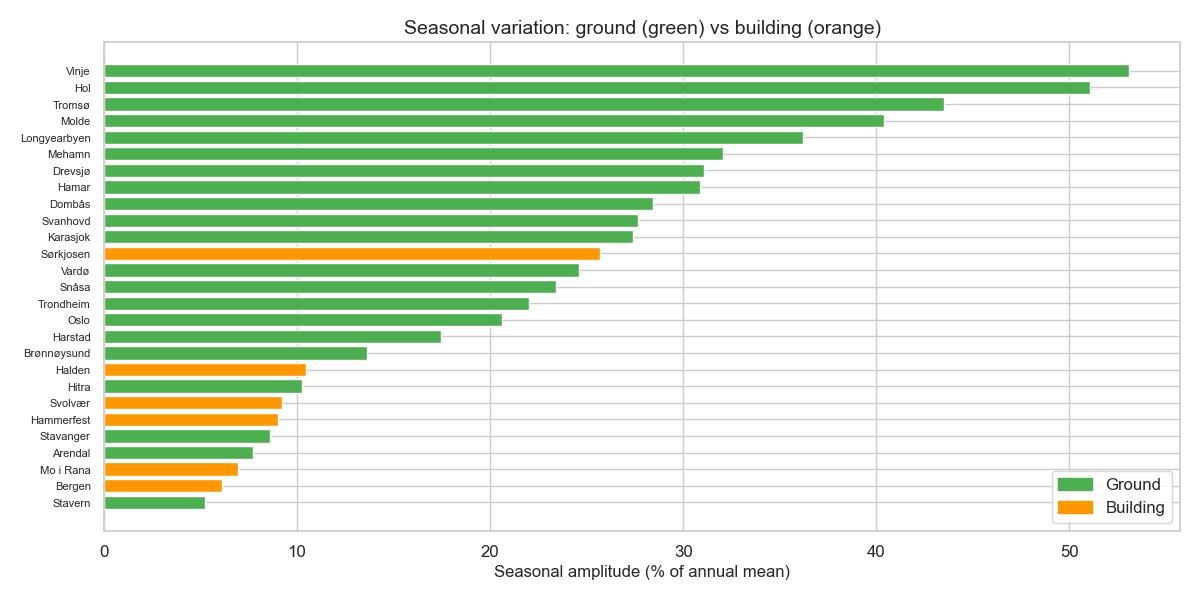

PosixPath('/Users/anderskielland/Documents/Søknader/jobb_søk/JobbSøk6/DSA/intervju_tasks/Radiation/figures/seasonal_amplitude_by_placement.png')

In [25]:
# Statistical test: ground vs building seasonal amplitude
ground_amp = seasonal_amp.loc[seasonal_amp.index.get_level_values("placement") == "ground", "amplitude_pct"]
building_amp = seasonal_amp.loc[seasonal_amp.index.get_level_values("placement") == "building", "amplitude_pct"]

print(f"Ground stations (n={len(ground_amp)}):   median amplitude = {ground_amp.median():.1f}%")
print(f"Building stations (n={len(building_amp)}): median amplitude = {building_amp.median():.1f}%")

if len(building_amp) >= 2:
    stat, pval = stats.mannwhitneyu(ground_amp, building_amp, alternative="greater")
    print(f"\nMann-Whitney U (ground > building): p={pval:.4f}")
else:
    print("\n(Too few building stations for formal test)")

# Bar chart
fig, ax = plt.subplots(figsize=(12, 6))
colors = ["#4CAF50" if p == "ground" else "#FF9800" 
          for p in seasonal_amp.index.get_level_values("placement")]
ax.barh(range(len(seasonal_amp)), seasonal_amp["amplitude_pct"], color=colors)
ax.set_yticks(range(len(seasonal_amp)))
ax.set_yticklabels(seasonal_amp.index.get_level_values("station"), fontsize=8)
ax.set_xlabel("Seasonal amplitude (% of annual mean)")
ax.set_title("Seasonal variation: ground (green) vs building (orange)")
ax.invert_yaxis()
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#4CAF50", label="Ground"), Patch(color="#FF9800", label="Building")])
plt.tight_layout()
plt.show()
save_figure(fig, "seasonal_amplitude_by_placement")


## 3. Residual analysis — finding anomalies

DSA's current alarm criterion is a doubling of dose rate vs the 10-day rolling mean or median (har to interpret: "Eit generelt alarmkriteria for stasjonane er ei dobling av doseraten samanlikna med doseraten frå bakgrunnen over dei siste 10 dagane").    
We replicate this approach: compute a rolling 10-day median baseline, subtract it, and examine what remains.

Peaks in the residual are either radon washout (short, sharp spikes coinciding with rain) or genuine anomalies. Since DSA confirms no real incidents in 2023, all peaks should be explainable as natural variation.

In [6]:
# Compute rolling baseline and residuals for selected stations
selected = ["Oslo", "Vinje", "Tromsø", "Bergen", "Svanhovd"]
residuals = {}
all_peaks = []

for station in selected:
    ts = (
        radnett[radnett["station_name"] == station]
        .set_index("time")["dose_rate_clean"]
        .sort_index()
    )
    # 10-day rolling median baseline (240 hours)
    baseline = ts.rolling(240, center=True, min_periods=120).median()
    resid = (ts - baseline).dropna()
    residuals[station] = resid
    
    # Catalogue peaks > 3 sigma
    threshold = resid.mean() + 3 * resid.std()
    peaks = resid[resid > threshold]
    for t, v in peaks.items():
        sigma = (v - resid.mean()) / resid.std()
        all_peaks.append({"station": station, "time": t, "residual": v, "sigma": sigma})
    
    print(f"{station:15s} baseline_mean={baseline.mean():.4f}, resid_std={resid.std():.4f}, "
          f"peaks_3sig={len(peaks)}, threshold={threshold:.4f}")

peaks_df = pd.DataFrame(all_peaks).sort_values("sigma", ascending=False)
print(f"\nTotal peaks > 3 sigma across {len(selected)} stations: {len(peaks_df)}")

Oslo            baseline_mean=0.1226, resid_std=0.0035, peaks_3sig=157, threshold=0.0109
Vinje           baseline_mean=0.0840, resid_std=0.0039, peaks_3sig=149, threshold=0.0122
Tromsø          baseline_mean=0.0630, resid_std=0.0026, peaks_3sig=128, threshold=0.0079
Bergen          baseline_mean=0.1191, resid_std=0.0029, peaks_3sig=139, threshold=0.0090
Svanhovd        baseline_mean=0.0613, resid_std=0.0026, peaks_3sig=136, threshold=0.0079

Total peaks > 3 sigma across 5 stations: 709


In [7]:
# Top 20 largest residual peaks
print("Top 20 largest residual peaks (candidate anomalies):")
print(peaks_df.head(20).to_string(index=False))

# Check for Vinje Sept 28 — DSA report flags this as the largest relative increase
vinje_peaks = peaks_df[
    (peaks_df["station"] == "Vinje") &
    (peaks_df["time"].dt.month == 9) &
    (peaks_df["time"].dt.day >= 27) &
    (peaks_df["time"].dt.day <= 29)
]
if len(vinje_peaks) > 0:
    print(f"\nVinje Sept 28 peak (confirmed radon washout per DSA report):")
    print(vinje_peaks.to_string(index=False))
else:
    print("\nNote: Vinje Sept 28 not in peaks — checking raw data...")
    vinje_ts = radnett[
        (radnett["station_name"] == "Vinje") &
        (radnett["time"].dt.month == 9) &
        (radnett["time"].dt.day >= 27) &
        (radnett["time"].dt.day <= 29)
    ][["time", "dose_rate_clean"]]
    print(vinje_ts.to_string(index=False))

Top 20 largest residual peaks (candidate anomalies):
 station                time  residual   sigma
   Vinje 2023-09-28 11:00:00    0.0570 14.5419
  Bergen 2023-09-28 08:00:00    0.0410 13.9888
Svanhovd 2023-09-23 13:00:00    0.0330 12.7866
    Oslo 2023-08-07 10:00:00    0.0420 11.9287
    Oslo 2023-09-18 19:00:00    0.0410 11.6418
    Oslo 2023-08-20 05:00:00    0.0410 11.6418
    Oslo 2023-06-21 15:00:00    0.0410 11.6418
    Oslo 2023-08-07 11:00:00    0.0390 11.0680
   Vinje 2023-09-28 10:00:00    0.0430 10.9328
   Vinje 2023-09-18 16:00:00    0.0430 10.9328
Svanhovd 2023-09-12 15:00:00    0.0280 10.8359
    Oslo 2023-08-20 04:00:00    0.0360 10.2073
   Vinje 2023-09-18 15:00:00    0.0390  9.9017
   Vinje 2023-02-03 01:00:00    0.0385  9.7728
    Oslo 2023-08-20 03:00:00    0.0340  9.6335
  Bergen 2023-01-08 04:00:00    0.0280  9.5266
   Vinje 2023-09-18 17:00:00    0.0370  9.3861
    Oslo 2023-08-20 06:00:00    0.0330  9.3466
    Oslo 2023-06-21 14:00:00    0.0330  9.3466
Svanhov

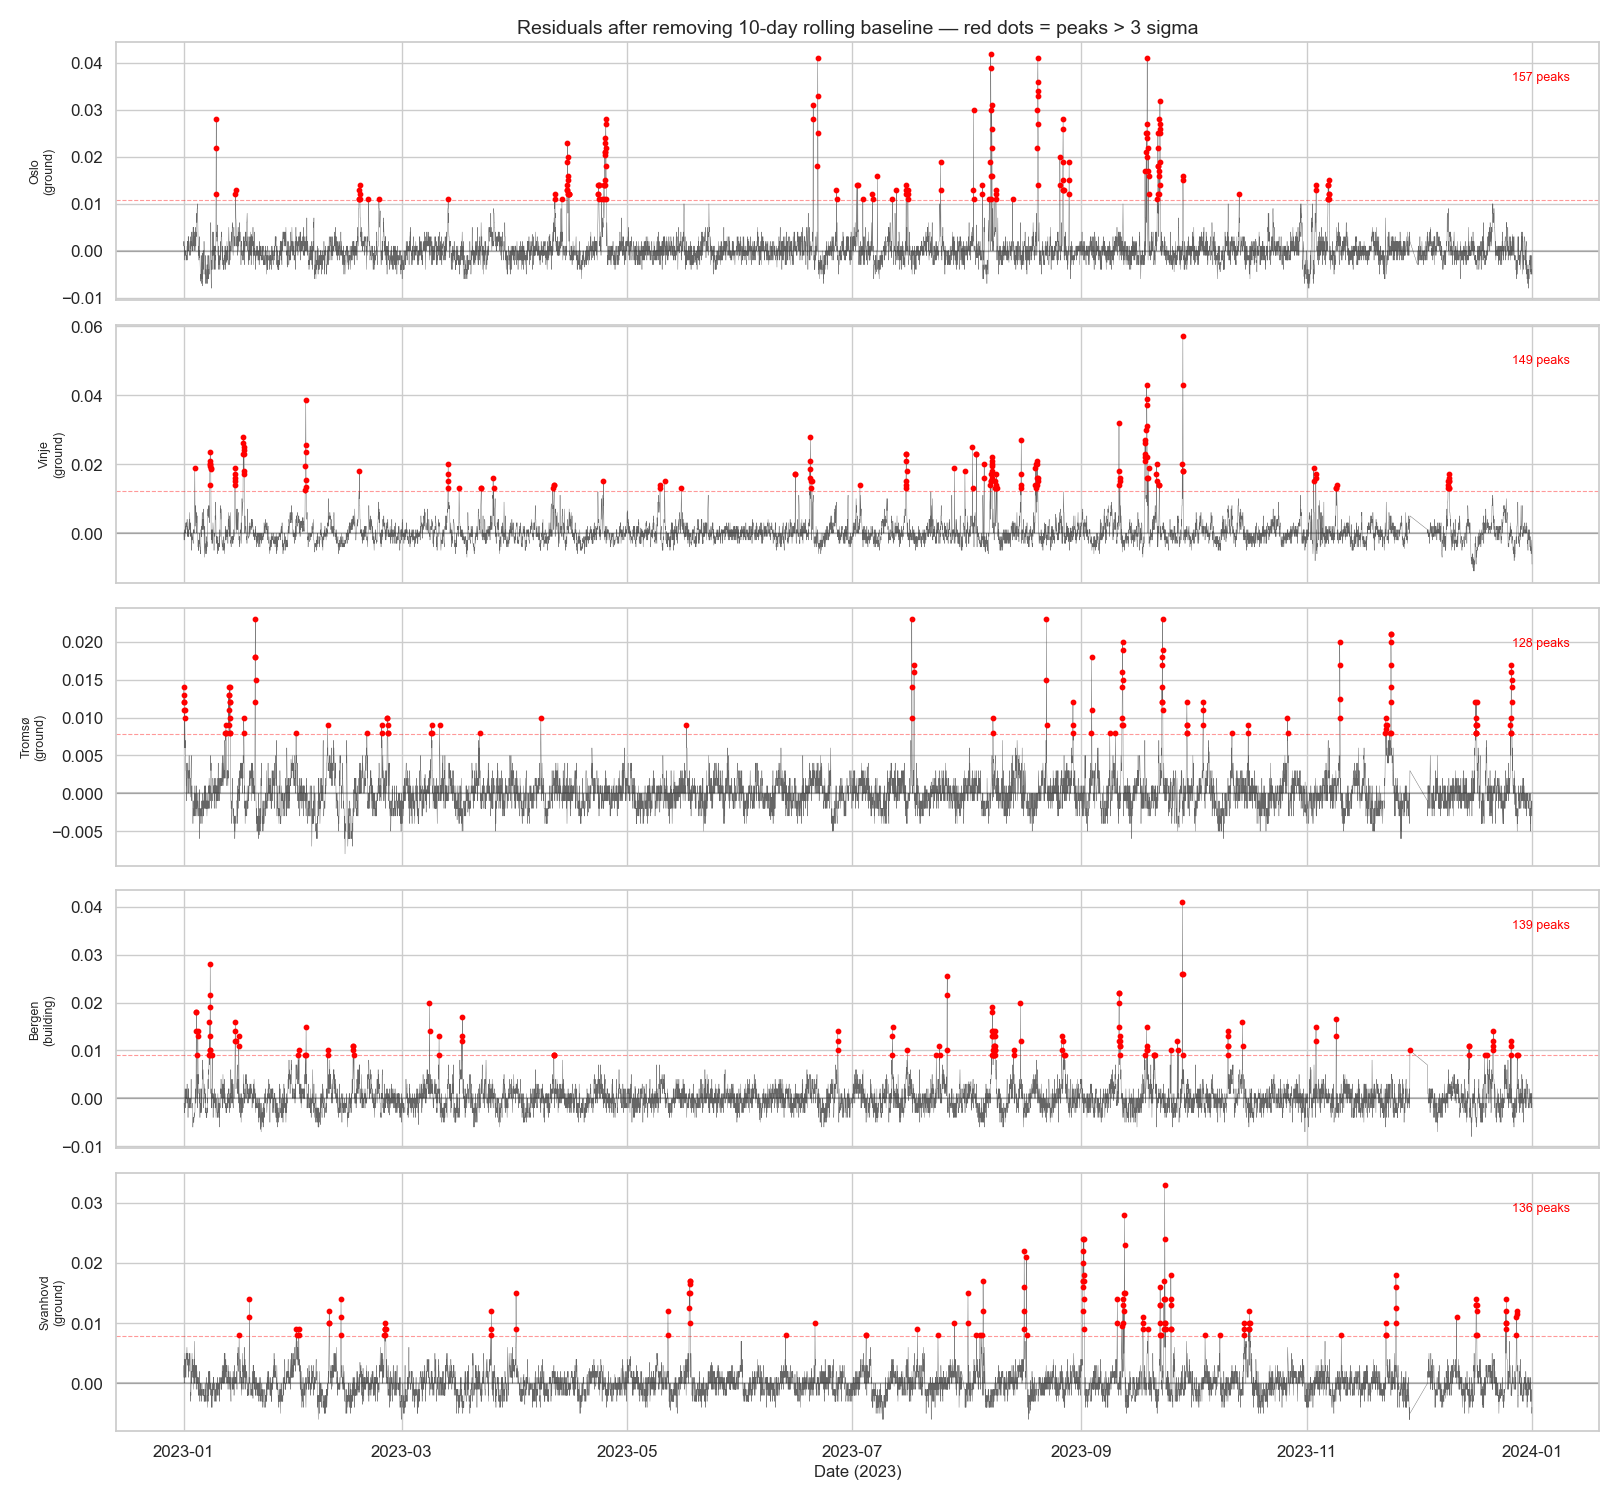

Spikes are candidate anomalies. In 2023, all are expected to be radon washout.
A real incident would appear as a sustained elevation, not a brief spike.


In [16]:
# Visualize residuals with peaks for two contrasting stations
fig, axes = plt.subplots(len(selected), 1, figsize=(16, 3 * len(selected)), sharex=True)

for i, station in enumerate(selected):
    resid = residuals[station]
    threshold = resid.mean() + 3 * resid.std()
    peak_mask = resid > threshold
    
    axes[i].plot(resid.index, resid.values, lw=0.3, color="#666")
    axes[i].scatter(resid.index[peak_mask], resid.values[peak_mask],
                    color="red", s=10, zorder=5)
    axes[i].axhline(threshold, color="red", ls="--", alpha=0.4, lw=0.8)
    axes[i].axhline(0, color="black", ls="-", alpha=0.2)
    p = placement_map.get(station, "?")
    n_p = peak_mask.sum()
    axes[i].set_ylabel(f"{station}\n({p})", fontsize=9)
    axes[i].text(0.98, 0.85, f"{n_p} peaks", transform=axes[i].transAxes, 
                ha="right", fontsize=9, color="red")

axes[-1].set_xlabel("Date (2023)")
axes[0].set_title("Residuals after removing 10-day rolling baseline — red dots = peaks > 3 sigma")
plt.tight_layout()
plt.show()
save_figure(fig, "residual_peaks_all_stations")

print("Spikes are candidate anomalies. In 2023, all are expected to be radon washout.")
print("A real incident would appear as a sustained elevation, not a brief spike.")

## 4. Comparison with DSA alarm criterion

DSA triggers an alarm when dose rate doubles compared to the 10-day background. How often would this trigger in normal 2023 data?

In [9]:
# DSA alarm: dose rate > 2 × 10-day rolling mean
alarm_counts = {}
for station in reliable_fixed:
    ts = (
        radnett[radnett["station_name"] == station]
        .set_index("time")["dose_rate_clean"]
        .sort_index()
    )
    rolling_mean = ts.rolling(240, min_periods=120).mean()
    alarm_mask = ts > 2 * rolling_mean
    n_alarms = alarm_mask.sum()
    alarm_counts[station] = n_alarms

alarm_df = pd.Series(alarm_counts).sort_values(ascending=False)
alarm_df = alarm_df[alarm_df > 0]

print("Stations where DSA alarm criterion (2x 10-day mean) would trigger:")
for station, count in alarm_df.items():
    print(f"  {station:25s} {count:4d} hours ({count/8761*100:.2f}%)")

print(f"\nTotal alarm-hours across all stations: {alarm_df.sum()}")
print(f"\nDSA confirms all 2023 alarms were radon washout — none were real incidents.")
print("A weather-corrected threshold could potentially reduce these false alarms.")

Stations where DSA alarm criterion (2x 10-day mean) would trigger:

Total alarm-hours across all stations: 0

DSA confirms all 2023 alarms were radon washout — none were real incidents.
A weather-corrected threshold could potentially reduce these false alarms.


## Key Findings

*Fill in after running:*

1. Seasonal amplitude: ground vs building stations — quantified and significant?
2. Number of residual peaks (false alarm rate of current system)
3. Vinje Sept 28 event identified and validated?
4. DSA alarm criterion false-positive rate

**Analyses moved to separate notebooks:**
- Rain effect → `rain_effect.ipynb`
- Cross-station correlation → `station_information_value.ipynb`
- MET weather integration → `rain_effect.ipynb`

## Take-Home Message

*One sentence for DSA.*

## Acceptance Criteria

- [ ] Seasonal pattern quantified for all reliable fixed stations
- [ ] Ground vs building difference confirmed statistically
- [ ] Residual peaks catalogued for 5 representative stations
- [ ] Vinje Sept 28 correctly identified
- [ ] DSA alarm criterion false-positive rate estimated